<h1 style="text-align:center;">Probability of Default Credit Risk Model Training</h1>

<h4>Libraries Used</h4>

In [1]:
import numpy as np # linear algebra 
import pandas as pd # data processing 
import matplotlib.pyplot as plt # data visualisation 
import seaborn as sns # more data visualisation
from datetime import datetime

from sklearn.impute import SimpleImputer, KNNImputer # Imputation Methods for missing values
from sklearn.model_selection import train_test_split # split data into train and test
from sklearn.preprocessing import MinMaxScaler # scale the data between 0 - 1
from sklearn.metrics import classification_report,confusion_matrix, ConfusionMatrixDisplay # Model Evaluation 
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,roc_auc_score)
import json

from tensorflow.keras.models import Sequential # for building the model 
from tensorflow.keras.layers import Dense, Activation, Dropout # add the layers
from tensorflow.keras.optimizers import Adam # optimizer 
from tensorflow.keras.callbacks import EarlyStopping, TensorBoard # Early Stopping and Tensor Board
from tensorflow.keras.models import load_model # load the model

from imblearn.under_sampling import RandomUnderSampler # Balance the Data

In [2]:
data = pd.read_csv(r"C:\Users\Admin\Desktop\Credit_Risk_Platform\data\lending_club_loan_data_cleaned.csv") #CLEANED DATA

<h2 style="text-align:center;">PREPROCESSING DATA FOR PD MODEL</h2>

<p><b>1. Encode Traget Variable</b></p>

In [3]:
#ENCODING TARGET VARIABLE - loan amount 
def targetVariable(x):
    if(x=='Fully Paid'):
        return 1
    return 0

In [4]:
data['loan_status'] = data['loan_status'].apply(targetVariable) #apply func to all target variable

<p><b>2. Convert Categorical Variables to Numeric</b></p>

In [5]:
#CONVERT ALL CATEGORICAL VARIABLES TO NUMERIC 
# Start by listing all columns that are currently non-numeric
data.select_dtypes(['object']).columns

Index(['term', 'grade', 'sub_grade', 'home_ownership', 'verification_status',
       'issue_d', 'purpose', 'earliest_cr_line', 'initial_list_status',
       'application_type', 'address'],
      dtype='object')

<p><b>term</b></p>

In [6]:
# inspecting "term" variable 
data['term'].value_counts() # the output shows there are only 2 possible loan terms

term
36 months    300023
60 months     93441
Name: count, dtype: int64

In [7]:
# converting "term" variable to numeric 
data['term'] = data['term'].apply(lambda term: int(term[:3]))

<p><b>grade</b></p>

In [8]:
#inspecting grade variable 
#Since every grade is already represented within sub_grade, keeping both variables would be redundant.
data = data.drop('grade',axis=1) # remove grade varaible 

In [9]:
#CREATE DUMMY VARIABLES from the sub_grade variable 
subgrade_dummies = pd.get_dummies(data['sub_grade'],drop_first=True)
data = pd.concat([data.drop('sub_grade',axis=1),subgrade_dummies],axis=1)
#converts the categorical variable into multiple binary columns.

In [10]:
data.columns

Index(['loan_amnt', 'term', 'int_rate', 'installment', 'home_ownership',
       'annual_inc', 'verification_status', 'issue_d', 'loan_status',
       'purpose', 'dti', 'earliest_cr_line', 'open_acc', 'pub_rec',
       'revol_bal', 'revol_util', 'total_acc', 'initial_list_status',
       'application_type', 'mort_acc', 'pub_rec_bankruptcies', 'address', 'A2',
       'A3', 'A4', 'A5', 'B1', 'B2', 'B3', 'B4', 'B5', 'C1', 'C2', 'C3', 'C4',
       'C5', 'D1', 'D2', 'D3', 'D4', 'D5', 'E1', 'E2', 'E3', 'E4', 'E5', 'F1',
       'F2', 'F3', 'F4', 'F5', 'G1', 'G2', 'G3', 'G4', 'G5'],
      dtype='object')

<p><b>verification_status, application_type, initial_list_status, purpose</b></p>
<p>These variables need to be converted into dummy variables so they could be used by machine learning models.</p>

In [11]:
#create dummy variables
dummies = pd.get_dummies(data[['verification_status', 'application_type','initial_list_status','purpose' ]],drop_first=True)
#drop original columns 
data = data.drop(['verification_status', 'application_type','initial_list_status','purpose'],axis=1)
data = pd.concat([data,dummies],axis=1)

<p><b>home_ownership</b></p>


In [12]:
data['home_ownership'].value_counts() # output is 6 home ownership categories 

home_ownership
MORTGAGE    197109
RENT        158770
OWN          37443
OTHER          110
NONE            29
ANY              3
Name: count, dtype: int64

<p>Convert these to dummy variables, but replace NONE and ANY with OTHER, so that we end up with just 4 categories, MORTGAGE, RENT, OWN, OTHER</p>

In [13]:
#combine rare categories
data['home_ownership']=data['home_ownership'].replace(['NONE', 'ANY'], 'OTHER')
#create dummy variables
dummies = pd.get_dummies(data['home_ownership'],drop_first=True)
#remove original column
data = data.drop('home_ownership',axis=1)
data = pd.concat([data,dummies],axis=1)

<p><b>address</b></p>

In [14]:
data['address'].value_counts()

address
USCGC Smith\r\nFPO AE 70466                               8
USS Johnson\r\nFPO AE 48052                               8
USS Smith\r\nFPO AP 70466                                 8
USNS Johnson\r\nFPO AE 05113                              7
USCGC Miller\r\nFPO AA 22690                              6
                                                         ..
12951 Williams Crossing\r\nJohnnyville, DC 30723          1
0114 Fowler Field Suite 028\r\nRachelborough, LA 05113    1
953 Matthew Points Suite 414\r\nReedfort, NY 70466        1
7843 Blake Freeway Apt. 229\r\nNew Michael, FL 29597      1
USCGC Tran\r\nFPO AP 22690                                1
Name: count, Length: 391161, dtype: int64

<p>Since almost every borrower has a different address, the full address is not very useful for identifying default patterns</p>
<p>Therefore, using feature engineering, the address is transformed into a ZIP code feature, which preserves location information while reducing the complexity of the data for the model. </p>

In [15]:
#extract zip code from the address 
data['zip_code'] = data['address'].apply(lambda address:address[-5:])

In [16]:
data['zip_code'].value_counts()

zip_code
70466    56629
22690    56157
30723    56129
48052    55560
00813    45512
29597    45199
05113    45120
11650    11149
93700    11088
86630    10921
Name: count, dtype: int64

In [17]:
#convert zip code into dummy variables 
dummies = pd.get_dummies(data['zip_code'],drop_first=True)
#remove original columns 
data = data.drop(['zip_code','address'],axis=1)
data = pd.concat([data,dummies],axis=1)

<p><b>issue_d</b></p>
<p>The issue date variable was removed because it could introduce data leakage into the model. Data leakage occurs when a model uses information that would not be available at the time a lending decision is made. Therefore, this feature is dropped to ensure that the model is trained using only information available at the time of loan application.</p>

In [18]:
data = data.drop('issue_d',axis=1)

<p><b>earliest_cr_line</b></p>
<p>This variable records the month and year a borrower first opened a credit account.Since machine learning models cannot effectively use dates stored as text, the year is extracted and converted into a numerical feature. </p>

In [19]:
data['earliest_cr_line'].value_counts()

earliest_cr_line
Oct-2000    2999
Aug-2000    2911
Oct-2001    2878
Aug-2001    2869
Nov-2000    2723
            ... 
Feb-1957       1
Sep-1961       1
Nov-1955       1
Aug-1962       1
Aug-1959       1
Name: count, Length: 683, dtype: int64

In [20]:
#extract 4 last characters from each date (the year) 
data['earliest_cr_year'] = data['earliest_cr_line'].apply(lambda date:int(date[-4:]))
data = data.drop('earliest_cr_line',axis=1)

In [21]:
#listing all columns that are currently non-numeric
data.select_dtypes(['object']).columns

Index([], dtype='object')

<p>All categorical variables were successfully converted into numerical features using encoding and feature engineering techniques. As a result, the dataset now contains only numerical variables and is ready for machine learning model development.</p>

<p><b>3. Split into train/test sets </b></p>

In [22]:
#set x and y variables to the values of the featues and label 
x = data.drop('loan_status',axis=1).values
y = data['loan_status'].values

In [23]:
x[:5]

array([[10000.0, 36, 11.44, 329.48, 117000.0, 26.24, 16.0, 0.0, 36369.0,
        41.8, 25.0, 0.0, 0.0, False, False, False, False, False, False,
        False, True, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, True, False, True, False, False, False,
        False, False, False, False, False, False, False, False, True,
        False, False, False, True, False, False, True, False, False,
        False, False, False, False, 1990],
       [8000.0, 36, 11.99, 265.68, 65000.0, 22.05, 17.0, 0.0, 20131.0,
        53.3, 27.0, 3.0, 0.0, False, False, False, False, False, False,
        False, False, True, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, True, Fa

In [24]:
# Split the dataset into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(x,y,test_size=0.20,random_state=101)

In [25]:
scaler = MinMaxScaler() #Create Scaler 
X_train = scaler.fit_transform(X_train) # Learn from training data & scale it 
X_test = scaler.transform(X_test) # Also scale test data 

<h2 style="text-align:center;">PD MODEL DEVELOPMENT</h2>

In [26]:
# BUILDING BASELINE TENSORFLOW MODEL 
model_v1 = Sequential() #Create neural network 

model_v1.add(Dense(78, activation = 'relu')) #add 78 neruons 
model_v1.add(Dropout(0.2)) #drop 20%

model_v1.add(Dense(39, activation = 'relu')) # add 39 neurons 
model_v1.add(Dropout(0.2)) # drop 20%

model_v1.add(Dense(19, activation = 'relu')) # add 19 neurons 
model_v1.add(Dropout(0.2)) #drop 20%

model_v1.add(Dense(1, activation = 'sigmoid')) # Output probability of default

model_v1.compile(loss = 'binary_crossentropy', optimizer = 'adam');

In [27]:
model_v1.fit( X_train, y_train, #TRAIN model 
    epochs = 25, # train 25 times 
    batch_size = 256, # with 256 records at a time 
    validation_data = (X_test, y_test)); # Test the model 

Epoch 1/25
1230/1230 ━━━━━━━━━━━━━━━━━━━━ 22s 12ms/step - loss: 0.3040 - val_loss: 0.2628
Epoch 2/25
1230/1230 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - loss: 0.2662 - val_loss: 0.2613
Epoch 3/25
1230/1230 ━━━━━━━━━━━━━━━━━━━━ 19s 15ms/step - loss: 0.2635 - val_loss: 0.2607
Epoch 4/25
1230/1230 ━━━━━━━━━━━━━━━━━━━━ 13s 10ms/step - loss: 0.2619 - val_loss: 0.2603
Epoch 5/25
1230/1230 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - loss: 0.2613 - val_loss: 0.2603
Epoch 6/25
1230/1230 ━━━━━━━━━━━━━━━━━━━━ 13s 10ms/step - loss: 0.2610 - val_loss: 0.2604
Epoch 7/25
1230/1230 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - loss: 0.2604 - val_loss: 0.2604
Epoch 8/25
1230/1230 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - loss: 0.2600 - val_loss: 0.2597
Epoch 9/25
1230/1230 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - loss: 0.2596 - val_loss: 0.2598
Epoch 10/25
1230/1230 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - loss: 0.2592 - val_loss: 0.2595
Epoch 11/25
1230/1230 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - loss: 0.2591 - val_loss: 0.2593
Epoch 12/

In [28]:
#SAVE FIRST VERSION OF THE BASELINE MODEL 
model_v1.save(r"C:\Users\Admin\Desktop\Credit_Risk_Platform\models\pd_baselinemodel_v1.keras")

<h2 style="text-align:center;">EVALUATING PD MODEL PERFORMACE</h2>

<p> To evaluate how well the first version of the PD model predicts whether a loan will default or not, a training loss vs validation loss graph is plotted. This helps show how well the model is learning and whether it is overfitting or underfitting. It also helps determine whether additional training is improving the model.</p>
<ul>
    <li><b>Training Loss (loss): </b>Indicates how many errors the model makes on the data it learns from.</li>
    <li><b>Validation Loss (val_loss): </b>Indicates how many errors the model makes on data it has never seen before.</li>
</ul>

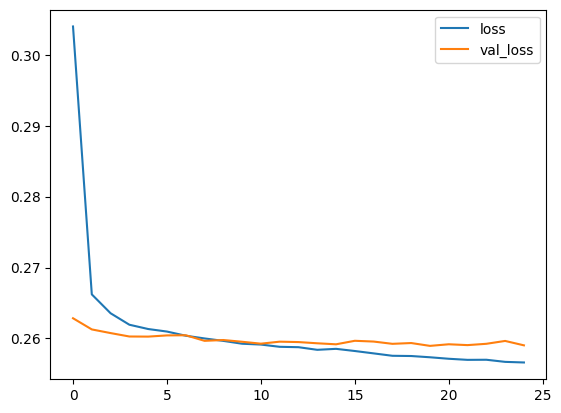

In [29]:
#Plot Validation loss Vs. the Training loss gragh 
losses = pd.DataFrame(model_v1.history.history) # store model 
losses[['loss','val_loss']].plot(); # plot model 

<p>The results showed that the training loss decreased quickly during the first few epochs, which means the model was learning patterns from the data. The validation loss stayed close to the training loss, showing that the model was also performing well on unseen data. There was no clear sign of overfitting, and the model seemed to reach a stable point at around 10 epochs, with only small improvements after that.</p>

In [62]:
#MAKE CLASSIFICATION REPORT showing, Precision, Recall, F1-Score, Accuracy 
y_pred_v1 = model_v1.predict(X_test)
predictions_v1 = np.round(y_pred_v1).astype(int)
report_v1 = classification_report(y_test,predictions_v1,output_dict=True) #report dictionary 
# Display report
print(classification_report(y_test, predictions_v1))

965/965 ━━━━━━━━━━━━━━━━━━━━ 1s 981us/step
              precision    recall  f1-score   support

           0       0.61      0.97      0.75     15365
           1       0.94      0.37      0.54     15513

    accuracy                           0.67     30878
   macro avg       0.77      0.67      0.64     30878
weighted avg       0.77      0.67      0.64     30878



In [63]:
#SAVING METRICS FOR THE FIRST VERSION OF THE PD MODEL 
metrics_v1 = { "Accuracy": report_v1["accuracy"],"Precision": report_v1["1"]["precision"],"Recall": report_v1["1"]["recall"],"F1-Score": report_v1["1"]["f1-score"]}
with open("../outputs/model_metrics_v1.json", "w") as f:
    json.dump(metrics_v1, f, indent=4)

<p><b>Confusion Matrix</b></p>

<p>The confusion matrix shows how well the model classified the two loan outcomes. It correctly identified 12,648 Fully Paid loans and 12,075 Not Fully Paid loans, while incorrectly classifying 2,717 and 3,438 loans respectively. Overall, the results are fairly balanced.</p>

965/965 ━━━━━━━━━━━━━━━━━━━━ 1s 835us/step


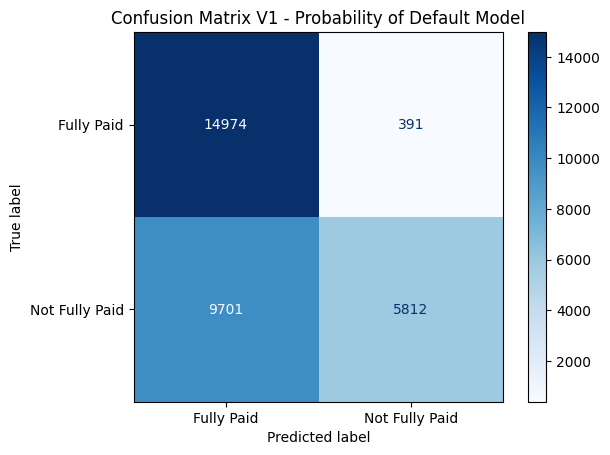

In [61]:
y_pred_prob_v1 = model_v1.predict(X_test)
y_pred_v1 = (y_pred_prob_v1 > 0.5).astype(int).flatten()

# Confusion Matrix
cm_v1 = confusion_matrix(y_test, y_pred_v1)
disp = ConfusionMatrixDisplay(
confusion_matrix=cm_v1,
display_labels=['Fully Paid', 'Not Fully Paid']
)
disp.plot(cmap='Blues')
plt.title('Confusion Matrix V1 - Probability of Default Model')
plt.show()

<p>The confusion matrix for PD BaselineModel V1 shows that the model performed well at identifying Fully Paid loans, correctly classifying 14,974 borrowers. However, it struggled with Not Fully Paid loans, correctly identifying only 5,812 and incorrectly classifying 9,701 as Fully Paid. This shows that the model was biased towards the majority class because the original data was imbalanced.</p>

<p><b>Percentage of Defaulted & Non Defaulted</b></p>

In [33]:
data['loan_status'].value_counts(normalize = True) * 100 # class percentages 
# Fully Paid = 1, other outcomes = 0

loan_status
1    80.380924
0    19.619076
Name: proportion, dtype: float64

<h3> Summary of PD BaselineModel Version 1</h3>
<p>The pd_baselinemodel_v1 achieved 67.31% accuracy, with 93.69% precision, 37.46% recall, and a 53.52% F1-score. However, the confusion matrix shows that the model still missed some Not Fully Paid borrowers, indicating some bias towards the Fully Paid class Overall, the model provides a reasonable baseline for predicting borrower risk and can be further by balancing the original data</p>
<br>
<br>

 <h2 style="text-align:center;"> Balance the Data and Re-Train</h2>

<p>The original dataset was imbalanced, with a much higher number of Fully Paid loans than Not Fully Paid loans. To address this imbalance, the data was balanced before retraining the the version1 PD model. This was done to give both classes a more equal representation and help the model better identify borrowers who may default.</p>

In [34]:
#balance and train classes in the dataset 
rus = RandomUnderSampler(sampling_strategy=1) # create undersampler & balance the classes
X_res, y_res = rus.fit_resample(x, y) # apply undersampling to X and Y 

In [35]:
pd.DataFrame(y).value_counts() # count record in classes deaulted and non defaulted 

0
1    316270
0     77194
Name: count, dtype: int64

In [36]:
pd.DataFrame(y_res).value_counts() # count record in classes AFTER BALANCING

0
0    77194
1    77194
Name: count, dtype: int64

<p><b>The data was balanced so that both classes had 77,194 records each. The model therefore needed to be retrained on this balanced data so it could learn from both classes equally and improve its ability to identify loan defaults.</p></b>

In [37]:
# Train test split
X_train, X_test, y_train, y_test = train_test_split(X_res, y_res, test_size=0.20, random_state=101)

# Scale the data
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Build the model
model_v2 = Sequential()
model_v2.add(Dense(78, activation = 'relu'))
model_v2.add(Dropout(0.2))
model_v2.add(Dense(39, activation = 'relu'))
model_v2.add(Dropout(0.2))
model_v2.add(Dense(19, activation = 'relu'))
model_v2.add(Dropout(0.2))
model_v2.add(Dense(1, activation = 'sigmoid'))

# Compile the model
model_v2.compile(loss = 'binary_crossentropy', optimizer = 'adam')

# Early stopping
early_stop = EarlyStopping(monitor='val_loss', mode='min', verbose=1, patience=25)

# Fit the model
model_v2.fit(X_train, y_train, epochs = 25, batch_size = 256, validation_data = (X_test, y_test));

Epoch 1/25
483/483 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - loss: 0.4490 - val_loss: 0.3661
Epoch 2/25
483/483 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 0.3715 - val_loss: 0.3620
Epoch 3/25
483/483 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 0.3651 - val_loss: 0.3603
Epoch 4/25
483/483 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 0.3622 - val_loss: 0.3601
Epoch 5/25
483/483 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 0.3610 - val_loss: 0.3587
Epoch 6/25
483/483 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.3600 - val_loss: 0.3584
Epoch 7/25
483/483 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 0.3591 - val_loss: 0.3590
Epoch 8/25
483/483 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 0.3588 - val_loss: 0.3587
Epoch 9/25
483/483 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.3585 - val_loss: 0.3582
Epoch 10/25
483/483 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.3574 - val_loss: 0.3582
Epoch 11/25
483/483 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.3569 - val_loss: 0.3585
Epoch 12/25
483/483 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/st

In [38]:
#SAVE SECOND VERSION OF BASELINE MODEL AFTER BALANCING
model_v2.save(r"C:\Users\Admin\Desktop\Credit_Risk_Platform\models\pd_baselinemodel_v2.keras")

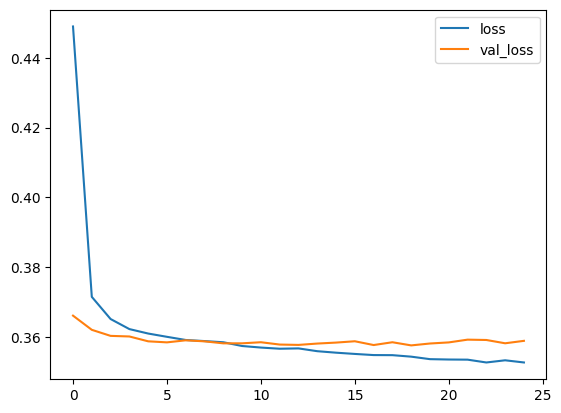

In [39]:
#EVALUATE V2 MODEL PERFORMANCE AFTER BALALCNING 
losses = pd.DataFrame(model_v2.history.history)
losses[['loss','val_loss']].plot();

<p>After balancing the data and retraining the model, the training and validation loss decreased and then stabilized. The two remained close, showing that the model was learning well without clear overfitting. Overall, the model showed better learning of both classes.</p>

In [66]:
y_pred_v2 = model_v2.predict(X_test)
predictions_v2 = np.round(y_pred_v2).astype(int)
report_v2 = classification_report(y_test,predictions_v2,output_dict=True) #report dictionary 
# Display report
print(classification_report(y_test, predictions_v2))

965/965 ━━━━━━━━━━━━━━━━━━━━ 1s 803us/step
              precision    recall  f1-score   support

           0       0.79      0.82      0.80     15365
           1       0.81      0.78      0.80     15513

    accuracy                           0.80     30878
   macro avg       0.80      0.80      0.80     30878
weighted avg       0.80      0.80      0.80     30878



In [67]:
#SAVING METRICS FOR THE second VERSION OF THE PD MODEL metrics 
metrics_v2 = { "Accuracy": report_v2["accuracy"],"Precision": report_v2["1"]["precision"],"Recall": report_v2["1"]["recall"],"F1-Score": report_v2["1"]["f1-score"]}
with open("../outputs/model_metrics_v2.json", "w") as f:
    json.dump(metrics_v2, f, indent=4)

<p><b>Confusion Matrix</b></p>

965/965 ━━━━━━━━━━━━━━━━━━━━ 1s 850us/step


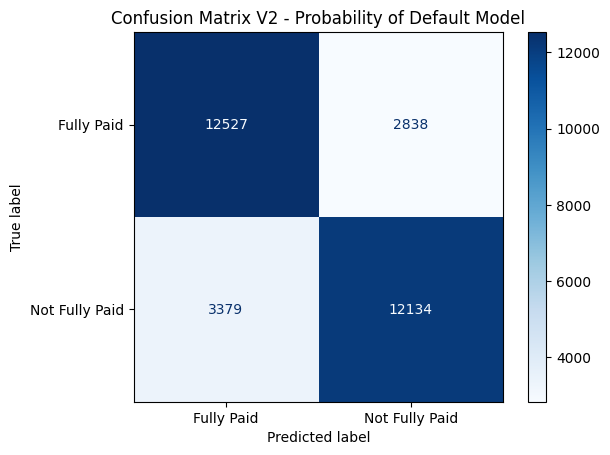

In [60]:
y_pred_prob_v2 = model_v2.predict(X_test)
y_pred_v2 = (y_pred_prob_v2 > 0.5).astype(int).flatten()

# Confusion Matrix
cm_v2 = confusion_matrix(y_test, y_pred_v2)
disp = ConfusionMatrixDisplay(
confusion_matrix=cm_v2,
display_labels=['Fully Paid', 'Not Fully Paid']
)
disp.plot(cmap='Blues')
plt.title('Confusion Matrix V2 - Probability of Default Model')
plt.show()

<p>The confusion matrix for PD BaselineModel V2 shows that the model performed more evenly after balancing the dataset. It correctly identified 12,527 Fully Paid and 12,134 Not Fully Paid loans, with fewer differences between the two classes. This shows that V2 improved its ability to identify Not Fully Paid borrowers, making it more useful for credit risk prediction.</p>

<h3>Summary of PD BaselineModel Version 2 (Balanced Model)</h3>
<p>The pd_baselinemodel_v2 achieved 79.9% accuracy, with 81% precision, 78.2% recall, and 79.69% F1-score. After balancing the data, the model performed more evenly across both Fully Paid and Not Fully Paid loans, with an F1-score of about 80% for each class. The confusion matrix also shows that the model correctly identified 12,527 Fully Paid and 12,134 Not Fully Paid loans. This shows that V2 was better at identifying both classes and reducing the bias towards the majority class.</p>
<br>
<br>

 <h2 style="text-align:center;">TENSORBOARD: Visulize the PD model </h2>

<p>This section uses TensorBoard to monitor the PD model while it is training. It helps us view the training and validation loss, track the model’s learning, and check for overfitting. A TensorFlow callback records this information after each epoch so the training process can be viewed through graphs in TensorBoard.</p>

In [43]:
datetime.now().strftime("%Y-%m-%d--%H%M")

'2026-10-01--1523'

In [44]:
# Create the call back
log_directory = 'logs/fit'

board = TensorBoard(log_dir=log_directory,histogram_freq=1,
    write_graph=True,
    write_images=True,
    update_freq='epoch',
    profile_batch=2,
    embeddings_freq=1)

<p><b>The model is trained again with the TensorBoard callback so that its training progress can be recorded and monitored.</b></p>

In [45]:
# Train test split
X_train, X_test, y_train, y_test = train_test_split(X_res, y_res, test_size=0.20, random_state=101)

# Scale the data
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Build the model
model_v3 = Sequential()
model_v3.add(Dense(78, activation = 'relu'))
model_v3.add(Dropout(0.2))
model_v3.add(Dense(39, activation = 'relu'))
model_v3.add(Dropout(0.2))
model_v3.add(Dense(19, activation = 'relu'))
model_v3.add(Dropout(0.2))
model_v3.add(Dense(1, activation = 'sigmoid'))

# Compile the model
model_v3.compile(loss = 'binary_crossentropy', optimizer = 'adam');

# Early stopping
early_stop = EarlyStopping(monitor='val_loss', mode='min', verbose=1, patience=25);

# Fit the model after adding the call back named board
model_v3.fit(X_train, y_train, epochs = 25, batch_size = 256, validation_data = (X_test, y_test), callbacks = [board]);

Epoch 1/25
483/483 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - loss: 0.4421 - val_loss: 0.3667
Epoch 2/25
483/483 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 0.3715 - val_loss: 0.3622
Epoch 3/25
483/483 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - loss: 0.3652 - val_loss: 0.3606
Epoch 4/25
483/483 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - loss: 0.3635 - val_loss: 0.3600
Epoch 5/25
483/483 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - loss: 0.3617 - val_loss: 0.3583
Epoch 6/25
483/483 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 0.3607 - val_loss: 0.3583
Epoch 7/25
483/483 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.3593 - val_loss: 0.3587
Epoch 8/25
483/483 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 0.3588 - val_loss: 0.3588
Epoch 9/25
483/483 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 0.3583 - val_loss: 0.3587
Epoch 10/25
483/483 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 0.3578 - val_loss: 0.3590
Epoch 11/25
483/483 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.3577 - val_loss: 0.3589
Epoch 12/25
483/483 ━━━━━━━━━━━━━━━━━━━━ 

In [46]:
#SAVE THIRD VERSION OF BASELINE MODEL AFTER ADDING TENSORBOARD MONITORING 
model_v3.save(r"C:\Users\Admin\Desktop\Credit_Risk_Platform\models\pd_baselinemodel_v3.keras")

In [47]:
from tensorboard import notebook  # Import TensorBoard tools
notebook.start("--logdir logs/fit --port 6006")  # Start TensorBoard
notebook.display(port=6006, height=1000)  # Display TensorBoard

Selecting TensorBoard with logdir logs/fit (started 0:00:00 ago; port 6006, pid 19060).


 <h2 style="text-align:center;">Generate Borrower Risk Scores for Power BI </h2>

In [68]:
#CREATING DATAFRAME FOR BORROWER RISK SCORES 
y_pred_prob = model_v2.predict(X_test) 

# dataframe with borrower id's and their probability of default predictions 
borrower_scores = pd.DataFrame({
    "Borrower_ID": range(1, len(y_pred_prob)+1),
    "PD": y_pred_prob.flatten()
})

#assigning risk categories 
def risk_category(pd_score):
    if pd_score < 0.10:
        return "Low Risk"
    elif pd_score < 0.30:
        return "Medium Risk"
    else:
        return "High Risk"
#apply risk category function to df
borrower_scores["Risk_Category"] = (
borrower_scores["PD"].apply(risk_category))

#buisness recomendations
def recommendation(pd_score):
    if pd_score < 0.10:
        return "Standard Review"
    elif pd_score < 0.30:
        return "Manual Review"
    else:
        return "Reject"
# apply reccomendation function to df
borrower_scores["Recommendation"] = (
borrower_scores["PD"].apply(recommendation))

borrower_scores.head()

965/965 ━━━━━━━━━━━━━━━━━━━━ 1s 840us/step


,Borrower_ID,PD,Risk_Category,Recommendation
0,1,0.235981,Medium Risk,Manual Review
1,2,0.646230,High Risk,Reject
2,3,0.999998,High Risk,Reject
3,4,0.582423,High Risk,Reject
4,5,1.000000,High Risk,Reject


In [69]:
#Save borrower risk scores for dashboard 
borrower_scores.to_csv("../outputs/PDModel_borrower_scores.csv",index=False)